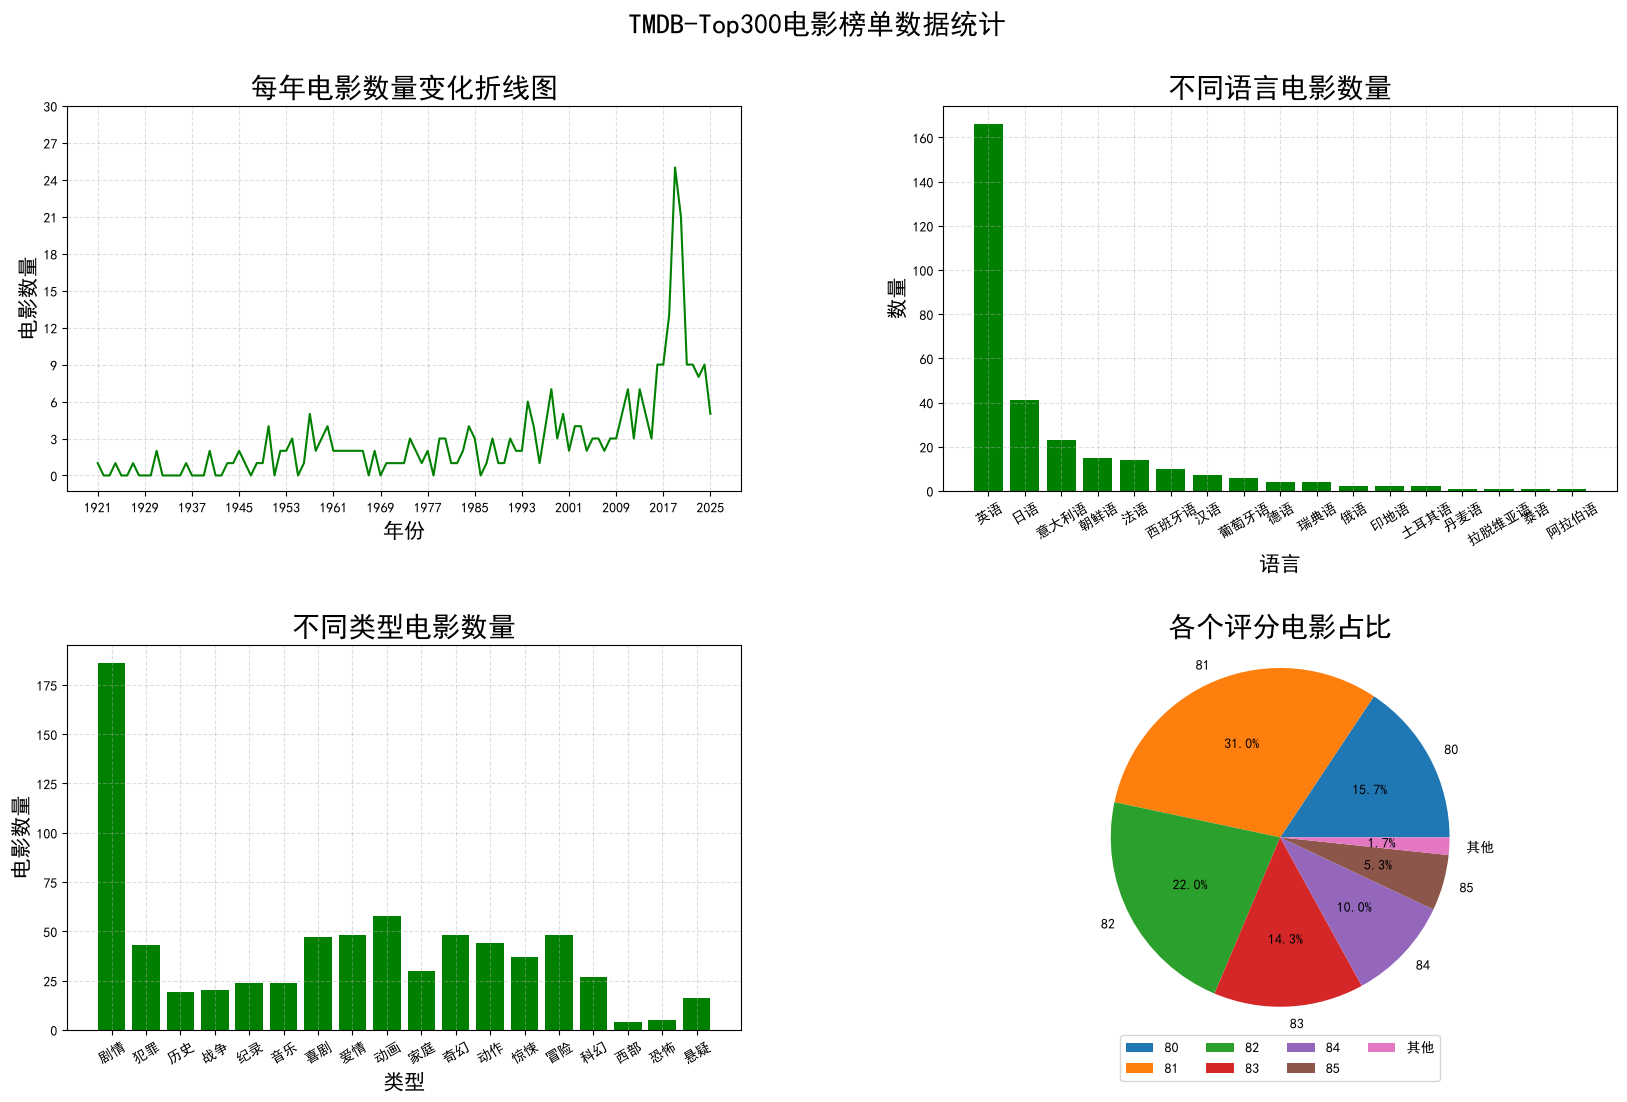

In [40]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import pandas as pd

#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建子图
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 12),dpi=100)
fig.subplots_adjust(hspace=0.4, wspace=0.3)

#设置大标题
fig.suptitle("TMDB-Top300电影榜单数据统计", fontsize=20,x=0.5,y=0.96)

#获取子图
ax1:Axes = ax[0][0]
ax2:Axes = ax[0][1]
ax3:Axes = ax[1][0]
ax4:Axes = ax[1][1]

#加载数据
data = pd.read_csv("data/movies.csv",usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})

#1.统计每一年上映的电影数量折线图
#1.1缺失值，异常值处理
# data.isnull().sum().to_frame()
data['年份'] = data['年份'].fillna(data['上映时间'].str[0:4])

#1.2分组统计
year_count = data.groupby('年份')['年份'].count()

#1.3组装数据
#x轴
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year,max_year+1)]
#y轴
y = [year_count.get(i,0) for i in x]

#1.4绘图
ax1.plot(x,y,color='g')
ax1.set_title('每年电影数量变化折线图',fontsize=20)
ax1.set_xlabel('年份',fontsize=15)
ax1.set_ylabel('电影数量',fontsize=15)

ax1.set_xticks(x[::8])
y_ticks = [i for i in range(0,31,3)]
ax1.set_yticks(y_ticks)

ax1.grid(linestyle='--',alpha=0.4)

#2.统计对比不同语言的电影数量柱状图

#2.1分组统计
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)
# print(language_count)
x_language = language_count.index.tolist()
y_language_count = language_count.values.tolist()

#2.2绘图
ax2.bar(x_language,y_language_count,color='g',width=0.8)
ax2.set_title('不同语言电影数量',fontsize=20)
ax2.set_xlabel('语言',fontsize=15)
ax2.set_ylabel('数量',fontsize=15)
ax2.grid(linestyle='--',alpha=0.4)
ax2.tick_params(axis='x',rotation=30,labelsize=10)

#3.统计对比不同类型的电影数量柱状图
#3.1获取不同类型电影数量
type_count = {} #字典存储
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type]+=1
        else :
            type_count[type]=1

x_types = list(type_count.keys())
y_values = list(type_count.values())

#3.2绘图
ax3.bar(x_types,y_values,color='g',width=0.8)
ax3.set_title('不同类型电影数量',fontsize=20)
ax3.set_xlabel('类型',fontsize=15)
ax3.set_ylabel('电影数量',fontsize=15)
ax3.grid(linestyle='--',alpha=0.4)
ax3.tick_params(axis='x',rotation=30,labelsize=10)

#4.各个评分电影占比饼状图
#4.1分组统计
rate_count = data.groupby('评分')['评分'].count()

#合并小数据成其他
total = rate_count.sum()
large_score = rate_count.loc[rate_count>=total*0.05]  #大数据
small_score = rate_count.loc[rate_count<total*0.05]  #小数据

if small_score.shape[0]>0:
    large_score['其他'] = small_score.sum()

rates = large_score.index.tolist()
values = large_score.values.tolist()

#4.2 绘图
ax4.pie(values,labels=rates,autopct='%1.1f%%',startangle=0, radius=1.1)  #startangle控制饼图起始角度
ax4.set_title('各个评分电影占比', fontsize=20)  # 设置标题
ax4.legend(loc='lower center',ncol=4, bbox_to_anchor=(0.5,-0.15))  #设置图例:loc:位置; ncol:列数 bbox_to_anchor(0.5:水平居中, -0.1:垂直居下)

#5.保存图片
plt.savefig("data/tmdb_top300_movies_data_statistics.png")

plt.show()
